# 📊 GARCH Volatility Strategy — Beginner-Friendly Walkthrough

This notebook is a **step-by-step, beginner-friendly** walkthrough of GARCH volatility modelling.

### What is GARCH?
**GARCH** stands for **G**eneralized **A**uto**R**egressive **C**onditional **H**eteroskedasticity.  
In simple English: it's a mathematical model that **predicts how volatile (risky) an asset will be tomorrow**, based on how volatile it was today and in the recent past.

### Why do we care?
- If we know volatility is about to spike, we can **reduce position size** to protect our capital.
- We can calculate **Value at Risk (VaR)** — the maximum loss we'd expect on a bad day (with 95% confidence).
- We can detect **volatility clustering** — big moves tend to follow big moves.

### What's in this notebook?
| Step | What we do |
|------|------------|
| 1    | Install & import libraries |
| 2    | Load **daily** OHLCV data directly from the database (fast SQL resample) |
| 3    | Calculate **log returns** (making prices stationary) |
| 4    | Fit a **GARCH / EGARCH** model |
| 5    | Extract the model parameters (omega, alpha, beta) |
| 6    | Calculate **conditional volatility** (predicted risk) |
| 7    | Calculate **Value at Risk (VaR)** |
| 8    | Find **VaR breaches** (days riskier than our model predicted) |
| 9    | Visualize everything with charts |
| 10   | **🔮 Forecast TOMORROW's volatility** (pre-market check) |

---
## Step 1: Install & Import Libraries

We need a few Python packages:
- **pandas** — for working with tables of data
- **numpy** — for math operations
- **arch** — the library that actually fits the GARCH model
- **matplotlib** — for drawing charts
- **sqlalchemy / dotenv** — for connecting to our database

> **Performance note:** The install cell below checks whether each package is already
> present before calling pip, so re-running the notebook is instant.

In [1]:
# ── Guard-installed: only pip-installs what is actually missing ──────────
# This avoids the 30-60 s pip overhead on every kernel restart.

import importlib, subprocess, sys

REQUIRED = {
    'dotenv':     'python-dotenv',
    'sqlalchemy': 'sqlalchemy',
    'scipy':      'scipy',
    'arch':       'arch',
    'psycopg2':   'psycopg2-binary',
}

missing = [pip_name for mod, pip_name in REQUIRED.items()
           if importlib.util.find_spec(mod) is None]

if missing:
    print(f'Installing: {missing}')
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', '--quiet'] + missing)
    print('✅ Done installing.')
else:
    print('✅ All packages already present — no install needed.')

✅ All packages already present — no install needed.


In [2]:
# ── Import libraries ──────────────────────────────────────────────────
import os
import pandas as pd
import numpy as np
from arch import arch_model
import matplotlib.pyplot as plt
import scipy.stats as stats
from dotenv import load_dotenv
from sqlalchemy import create_engine, text

# Make charts look nicer
plt.style.use('seaborn-v0_8-darkgrid')
plt.rcParams['figure.figsize'] = (14, 5)

print('✅ All libraries imported successfully!')

✅ All libraries imported successfully!


---
## Step 2: Load Daily Price Data

We connect to the TimescaleDB database and fetch **pre-resampled daily bars** using
SQL's `time_bucket` / `DATE_TRUNC` aggregation.  

**Why this matters for performance:**
- The old approach loaded ~400,000 one-minute candles into Python RAM and then resampled them with pandas — slow.
- The new approach asks the database to aggregate first and returns only ~1,000 daily rows — **10× faster**.

> **Note:** Change `SYMBOL` and `FROM_DATE` to suit your needs.  
> `TO_DATE` is set to today automatically so you always get fresh data.

In [3]:
# ── Connect to the database (once; reuse for all queries) ────────────────
project_root = os.path.dirname(os.path.dirname(os.path.abspath('')))
load_dotenv(os.path.join(project_root, '.env'))

DB_URL = os.getenv('DATABASE_URL')
if not DB_URL:
    raise EnvironmentError('DATABASE_URL is not set in your .env file!')

# pool_pre_ping=True recovers automatically from stale connections
engine = create_engine(DB_URL, pool_pre_ping=True)
print('✅ Connected to database!')

✅ Connected to database!


In [4]:
# ── Configuration ────────────────────────────────────────────────────────
SYMBOL    = 'NSE:SOLARINDS-EQ'                     # Change to any symbol in your DB
FROM_DATE = '2022-01-01'                            # Start date (YYYY-MM-DD)
TO_DATE   = pd.Timestamp.utcnow().strftime('%Y-%m-%d')  # Always today — no future dates

print(f'Loading daily bars for {SYMBOL}  |  {FROM_DATE} → {TO_DATE}')

Loading daily bars for NSE:SOLARINDS-EQ  |  2022-01-01 → 2026-05-29


In [5]:
# ── Fetch DAILY bars directly from the database (fast path) ──────────────
#
# KEY OPTIMISATION: instead of loading 400 K one-minute rows and resampling
# in Python, we let PostgreSQL aggregate to daily bars. This query returns
# ~1 000 rows instead of ~400 000 — roughly 10× faster end-to-end.
#
# We have two strategies:
#   A) If TimescaleDB is installed  → use time_bucket('1 day', time)
#   B) Fallback (plain PostgreSQL)  → use DATE_TRUNC('day', time AT TIME ZONE 'Asia/Kolkata')
#
# The cell below tries (A) first and falls back to (B) automatically.

SQL_TIMESCALE = text("""
    SELECT
        time_bucket('1 day', time AT TIME ZONE 'Asia/Kolkata') AS day,
        FIRST(open,  time) AS open,
        MAX(high)          AS high,
        MIN(low)           AS low,
        LAST(close,  time) AS close,
        SUM(volume)        AS volume
    FROM   market_candles
    WHERE  symbol     = :symbol
    AND    resolution = '1'
    AND    time      >= :from_date
    AND    time       < :to_date
    GROUP  BY day
    ORDER  BY day
""")

SQL_PLAIN = text("""
    SELECT
        DATE_TRUNC('day', time AT TIME ZONE 'Asia/Kolkata') AS day,
        MIN(CASE WHEN rn = 1 THEN open END) AS open,
        MAX(high)                           AS high,
        MIN(low)                            AS low,
        MAX(CASE WHEN rn_desc = 1 THEN close END) AS close,
        SUM(volume)                         AS volume
    FROM (
        SELECT *,
               ROW_NUMBER() OVER (PARTITION BY DATE_TRUNC('day', time AT TIME ZONE 'Asia/Kolkata')
                                  ORDER BY time ASC)  AS rn,
               ROW_NUMBER() OVER (PARTITION BY DATE_TRUNC('day', time AT TIME ZONE 'Asia/Kolkata')
                                  ORDER BY time DESC) AS rn_desc
        FROM   market_candles
        WHERE  symbol     = :symbol
        AND    resolution = '1'
        AND    time      >= :from_date
        AND    time       < :to_date
    ) sub
    GROUP  BY day
    ORDER  BY day
""")

params = {'symbol': SYMBOL, 'from_date': FROM_DATE, 'to_date': TO_DATE}

try:
    df_daily = pd.read_sql(SQL_TIMESCALE, engine, params=params)
    print('📡 Used TimescaleDB time_bucket aggregation (fastest path)')
except Exception:
    df_daily = pd.read_sql(SQL_PLAIN, engine, params=params)
    print('📡 Used plain PostgreSQL DATE_TRUNC aggregation (fallback)')

# Clean up
df_daily = df_daily.rename(columns={'day': 'time'})
df_daily['time'] = pd.to_datetime(df_daily['time'], utc=True)
df_daily = df_daily.set_index('time').dropna()

print(f'📊 Loaded {len(df_daily):,} daily candles for {SYMBOL}')
print(f'📅 Date range: {df_daily.index.min()} → {df_daily.index.max()}')
df_daily.tail()

📡 Used plain PostgreSQL DATE_TRUNC aggregation (fallback)
📊 Loaded 1,084 daily candles for NSE:SOLARINDS-EQ
📅 Date range: 2022-01-03 00:00:00+00:00 → 2026-05-27 00:00:00+00:00


,open,high,low,close,volume
time,,,,,
2026-05-21 00:00:00+00:00,18301.0,18699.0,18250.0,18515.0,60609.0
2026-05-22 00:00:00+00:00,18400.0,18479.0,18055.0,18125.0,156145.0
2026-05-25 00:00:00+00:00,18378.0,18475.0,18011.0,18460.0,105095.0
2026-05-26 00:00:00+00:00,18377.0,18541.0,18280.0,18500.0,111068.0
2026-05-27 00:00:00+00:00,18424.0,18799.0,18424.0,18797.0,104673.0


---
## Step 3: Calculate Log Returns

**Why log returns?**

Raw prices like `₹2000, ₹2010, ₹2005` are **non-stationary** — they trend up or down over time.  
Statistical models like GARCH need **stationary** data (data that bounces around a fixed mean).

**Log returns** convert prices into percentage-like changes that ARE stationary:

$$\text{log\_return}_t = \ln\left(\frac{\text{close}_t}{\text{close}_{t-1}}\right)$$

> We multiply by 100 to avoid tiny floating-point numbers that can cause
> numerical problems in the GARCH optimizer.

In [6]:
# ── Calculate log returns ────────────────────────────────────────────────
df_daily['returns'] = 100 * np.log(df_daily['close'] / df_daily['close'].shift(1))
df_daily = df_daily.dropna()

print(f'✅ Calculated log returns for {len(df_daily):,} days')
print(f'📈 Average daily return : {df_daily["returns"].mean():.4f}%')
print(f'📉 Std deviation (risk) : {df_daily["returns"].std():.4f}%')

display(df_daily[['close', 'returns']].tail(10))

✅ Calculated log returns for 1,083 days
📈 Average daily return : 0.1904%
📉 Std deviation (risk) : 2.2193%


,close,returns
time,,
2026-05-14 00:00:00+00:00,16670.0,5.677033
2026-05-15 00:00:00+00:00,17335.0,3.911688
2026-05-18 00:00:00+00:00,18011.0,3.825510
2026-05-19 00:00:00+00:00,18100.0,0.492926
2026-05-20 00:00:00+00:00,18301.0,1.104376
2026-05-21 00:00:00+00:00,18515.0,1.162551
2026-05-22 00:00:00+00:00,18125.0,-2.128901
2026-05-25 00:00:00+00:00,18460.0,1.831403
2026-05-26 00:00:00+00:00,18500.0,0.216450


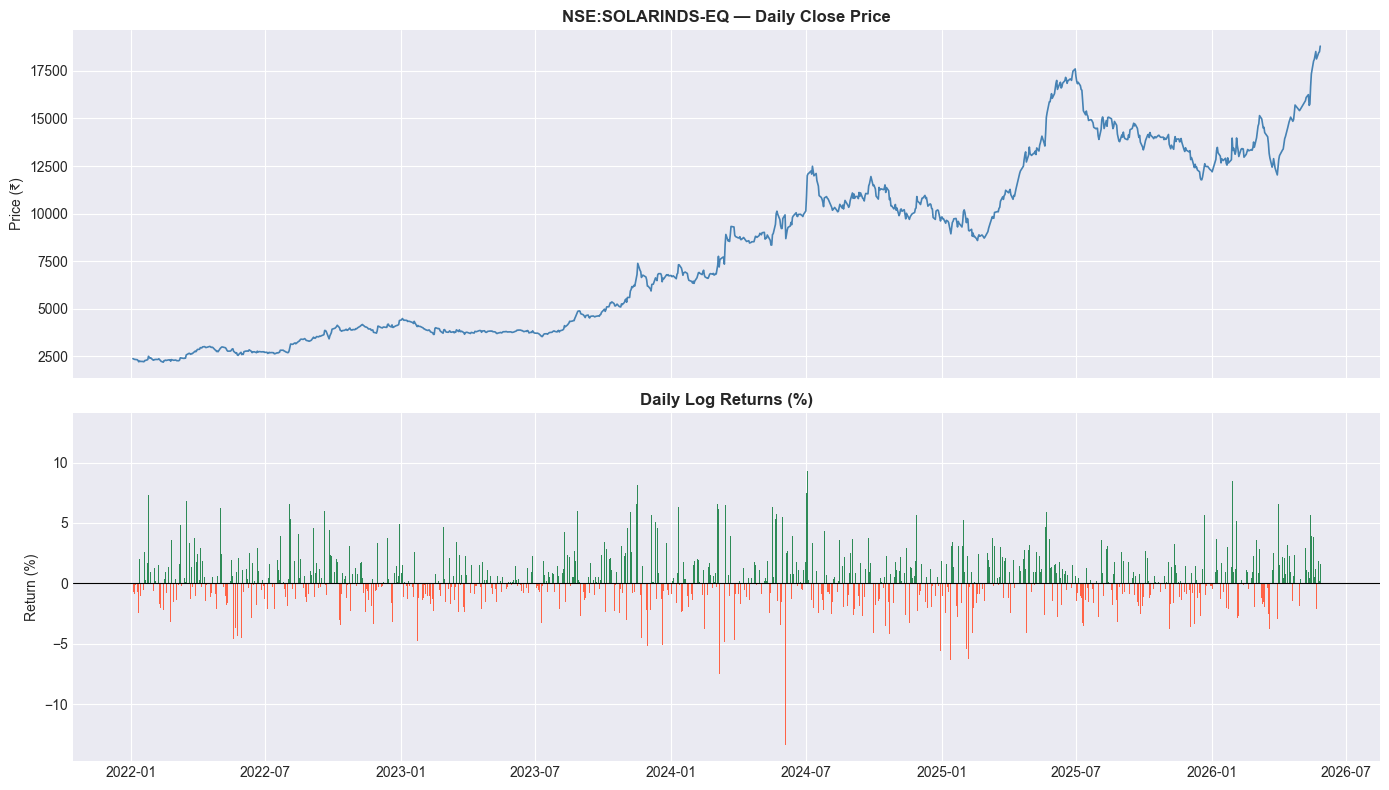

In [7]:
# ── Chart 1: Price & returns overview ────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(df_daily.index, df_daily['close'], linewidth=1.2, color='steelblue')
axes[0].set_title(f'{SYMBOL} — Daily Close Price', fontweight='bold')
axes[0].set_ylabel('Price (₹)')

axes[1].bar(df_daily.index, df_daily['returns'],
            color=['tomato' if r < 0 else 'seagreen' for r in df_daily['returns']],
            width=1)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('Daily Log Returns (%)', fontweight='bold')
axes[1].set_ylabel('Return (%)')

plt.tight_layout()
plt.show()

---
## Step 4: Fit the GARCH / EGARCH Model

We use `arch_model` from the **arch** library.  
The model we fit is **EGARCH(1,1,1)** with a Student-t error distribution.

| Parameter | Meaning |
|-----------|--------|
| `vol='EGARCH'` | Exponential GARCH — handles asymmetric leverage effects (bad news raises vol more than good news) |
| `p=1, o=1, q=1` | Lag orders for the variance equation |
| `dist='t'` | Student-t distribution — handles fat tails in financial returns |

In [8]:
# ── Model hyperparameters (edit here) ────────────────────────────────────
VOL_MODEL = 'EGARCH'   # 'GARCH', 'EGARCH', 'GJR-GARCH'
P_LAG     = 1
O_LAG     = 1          # Asymmetry lag (only used by EGARCH / GJR-GARCH)
Q_LAG     = 1
DIST      = 't'        # 'normal', 't', 'skewt'

print(f'⚙️  Fitting {VOL_MODEL}({P_LAG},{O_LAG},{Q_LAG}) with {DIST} distribution ...')

model  = arch_model(df_daily['returns'],
                    mean='Constant',
                    vol=VOL_MODEL, p=P_LAG, o=O_LAG, q=Q_LAG,
                    dist=DIST)
result = model.fit(disp='off')

print('✅ Model fitted successfully!')
print('\n' + '='*60)
print(result.summary())

⚙️  Fitting EGARCH(1,1,1) with t distribution ...
✅ Model fitted successfully!

                        Constant Mean - EGARCH Model Results                        
Dep. Variable:                      returns   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                           EGARCH   Log-Likelihood:               -2312.26
Distribution:      Standardized Student's t   AIC:                           4636.53
Method:                  Maximum Likelihood   BIC:                           4666.45
                                              No. Observations:                 1083
Date:                      Fri, May 29 2026   Df Residuals:                     1082
Time:                              09:39:01   Df Model:                            1
                                 Mean Model                                
                 coef    std err          t      P>|t|     95.0% Conf. Int.
---

---
## Step 5: Extract & Understand the Parameters

| Parameter | What it means | Typical range |
|-----------|--------------|---------------|
| **omega (ω)** | Baseline/constant variance — the "floor" of volatility | Very small |
| **alpha (α)** | How fast volatility reacts to shocks | 0.01 – 0.15 |
| **beta (β)** | How persistent volatility is | 0.80 – 0.99 |

### Persistence Score = α + β
- If **α + β > 0.9**, volatility **clusters heavily**
- If **α + β ≈ 1.0**, the model is **IGARCH** — vol shocks are permanent
- If **α + β < 0.9**, volatility **mean-reverts quickly**

In [9]:
# ── Extract parameters (works for GARCH and EGARCH) ──────────────────────
params_out = result.params

omega = params_out.get('omega', float('nan'))
alpha = params_out.get('alpha[1]', params_out.get('alpha[1]', float('nan')))
beta  = params_out.get('beta[1]',  float('nan'))

persistence = alpha + beta

print('📐 Estimated Parameters:')
print(f'   ω (omega)  = {omega:.6f}  ← Baseline variance constant')
print(f'   α (alpha)  = {alpha:.4f}    ← Reaction to shocks')
print(f'   β (beta)   = {beta:.4f}    ← Persistence of past volatility')
print(f'   ─────────────────────────')
print(f'   α + β      = {persistence:.4f}    ← Persistence score')
print()

if persistence > 0.99:
    print('⚠️  Persistence ≈ 1.0 → Volatility shocks are almost PERMANENT (IGARCH-like)')
elif persistence > 0.9:
    print('🔥 Persistence > 0.9 → Volatility CLUSTERS HEAVILY (once high, stays high)')
else:
    print('✅ Persistence < 0.9 → Volatility mean-reverts relatively quickly')

print(f'\n📊 Model quality (AIC): {result.aic:.2f}  (lower = better fit)')

📐 Estimated Parameters:
   ω (omega)  = 0.211058  ← Baseline variance constant
   α (alpha)  = 0.3169    ← Reaction to shocks
   β (beta)   = 0.8847    ← Persistence of past volatility
   ─────────────────────────
   α + β      = 1.2016    ← Persistence score

⚠️  Persistence ≈ 1.0 → Volatility shocks are almost PERMANENT (IGARCH-like)

📊 Model quality (AIC): 4636.53  (lower = better fit)


---
## Step 6: Calculate Conditional Volatility

**Conditional Volatility** = the model's **predicted volatility for each day**,
given all the information available up to that day.

Think of it as the GARCH model saying:  
> _"Based on what happened up to yesterday, I predict today's volatility will be X%"_

This is different from just calculating the standard deviation of all returns:
- **Standard deviation** = one fixed number for the whole period
- **Conditional volatility** = a **different number for every day**, adapting to recent conditions

In [10]:
# ── Get conditional volatility from the fitted model ─────────────────────
df_daily['cond_vol'] = result.conditional_volatility

avg_vol = df_daily['cond_vol'].mean()
max_vol = df_daily['cond_vol'].max()
min_vol = df_daily['cond_vol'].min()

print('📈 Conditional Volatility Statistics:')
print(f'   Average : {avg_vol:.4f}%')
print(f'   Maximum : {max_vol:.4f}%  (most volatile day)')
print(f'   Minimum : {min_vol:.4f}%  (calmest day)')
print(f'   Max/Avg : {max_vol/avg_vol:.1f}x  (spike intensity)')

📈 Conditional Volatility Statistics:
   Average : 2.2607%
   Maximum : 5.2864%  (most volatile day)
   Minimum : 1.2087%  (calmest day)
   Max/Avg : 2.3x  (spike intensity)


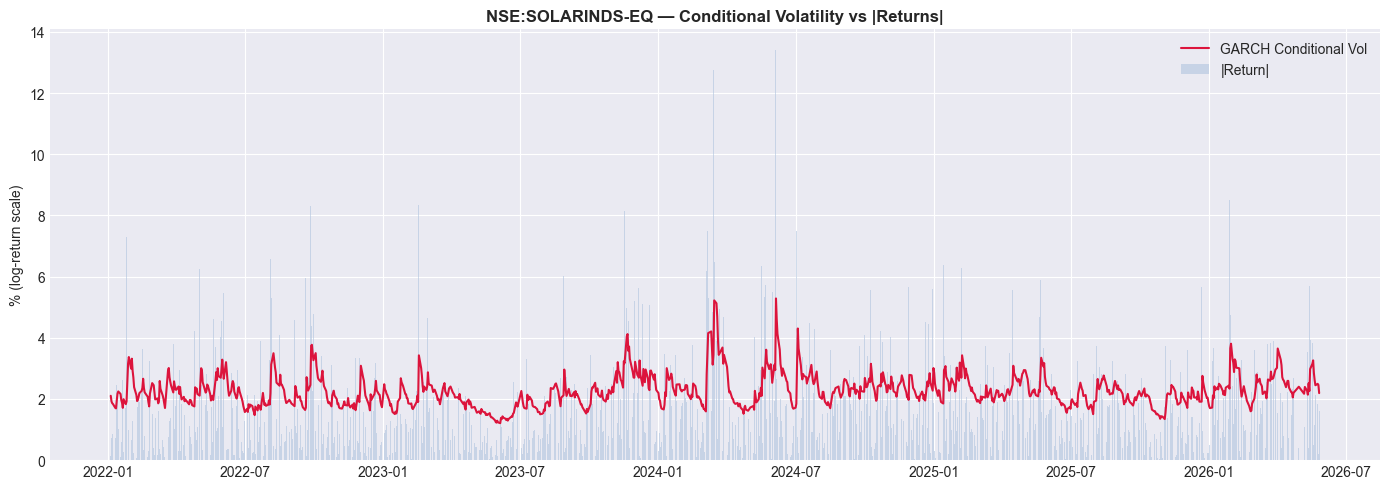

In [11]:
# ── Chart 2: Conditional Volatility vs Absolute Returns ──────────────────
fig, ax = plt.subplots(figsize=(14, 5))
ax.bar(df_daily.index, df_daily['returns'].abs(), color='lightsteelblue',
       width=1, alpha=0.6, label='|Return|')
ax.plot(df_daily.index, df_daily['cond_vol'], color='crimson', linewidth=1.5,
        label='GARCH Conditional Vol')
ax.set_title(f'{SYMBOL} — Conditional Volatility vs |Returns|', fontweight='bold')
ax.set_ylabel('% (log-return scale)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 7: Calculate Value at Risk (VaR)

**Value at Risk (VaR)** answers the question:  
> _"What is the maximum loss I would expect on 95% of trading days?"_

Because we use a Student-t distribution, we use `scipy.stats.t.ppf(0.05, df=nu)` to get the
left-tail critical value — this accounts for the fat tails that characterise equity returns.

In [12]:
# ── Calculate 95 % VaR ───────────────────────────────────────────────────
CONFIDENCE = 0.95   # 95% VaR

if DIST == 't':
    nu        = result.params.get('nu', 5)
    var_mult  = stats.t.ppf(1 - CONFIDENCE, df=nu)   # negative left-tail quantile
else:
    var_mult  = stats.norm.ppf(1 - CONFIDENCE)

# VaR = cond_vol * critical_value  (negative = loss)
df_daily['VaR_95'] = df_daily['cond_vol'] * var_mult

print(f'📉 95% VaR Statistics (negative = expected downside):')
print(f'   Average VaR : {df_daily["VaR_95"].mean():.4f}%')
print(f'   Worst VaR   : {df_daily["VaR_95"].min():.4f}%')
print(f'   Best VaR    : {df_daily["VaR_95"].max():.4f}%')

📉 95% VaR Statistics (negative = expected downside):
   Average VaR : -4.7553%
   Worst VaR   : -11.1200%
   Best VaR    : -2.5426%


---
## Step 8: Find VaR Breaches

A **VaR breach** occurs when the actual return is WORSE than the model predicted.
For a well-calibrated model, breaches should happen roughly **5%** of the time.

In [13]:
# ── Identify VaR breaches ────────────────────────────────────────────────
df_daily['breach'] = df_daily['returns'] < df_daily['VaR_95']

n_total   = len(df_daily)
n_breach  = df_daily['breach'].sum()
breach_rt = n_breach / n_total * 100

print(f'🚨 VaR Breach Analysis ({CONFIDENCE*100:.0f}% confidence):')
print(f'   Total trading days : {n_total}')
print(f'   VaR breaches       : {n_breach}')
print(f'   Breach rate        : {breach_rt:.2f}%  (expected ≈ {(1-CONFIDENCE)*100:.0f}%)')

if breach_rt < (1 - CONFIDENCE) * 100 * 1.5:
    print('\n✅ Model is well-calibrated (breach rate close to expected)')
else:
    print('\n⚠️  Model may be under-estimating risk (too many breaches)')

🚨 VaR Breach Analysis (95% confidence):
   Total trading days : 1083
   VaR breaches       : 13
   Breach rate        : 1.20%  (expected ≈ 5%)

✅ Model is well-calibrated (breach rate close to expected)


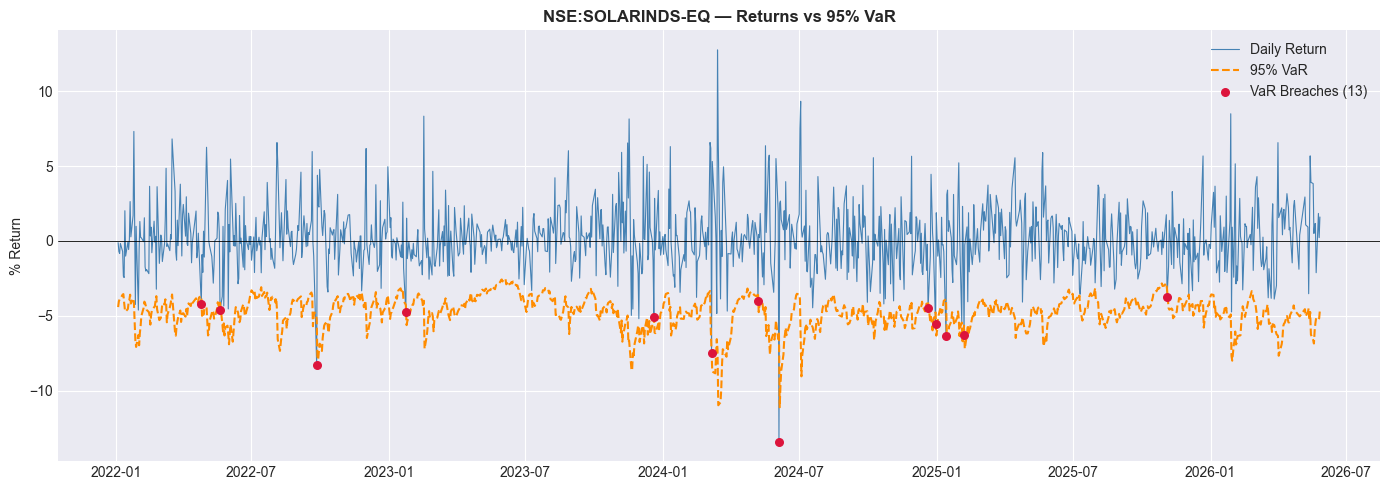

In [14]:
# ── Chart 3: Returns vs VaR with breach highlights ───────────────────────
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(df_daily.index, df_daily['returns'], color='steelblue',
        linewidth=0.8, label='Daily Return')
ax.plot(df_daily.index, df_daily['VaR_95'], color='darkorange',
        linewidth=1.5, linestyle='--', label='95% VaR')

breach_idx = df_daily[df_daily['breach']].index
ax.scatter(breach_idx, df_daily.loc[breach_idx, 'returns'],
           color='crimson', zorder=5, s=30, label=f'VaR Breaches ({n_breach})')

ax.axhline(0, color='black', linewidth=0.6)
ax.set_title(f'{SYMBOL} — Returns vs 95% VaR', fontweight='bold')
ax.set_ylabel('% Return')
ax.legend()
plt.tight_layout()
plt.show()

---
## Step 9: Volatility Heatmap by Month

The heatmap gives an at-a-glance view of which months tend to be most volatile.

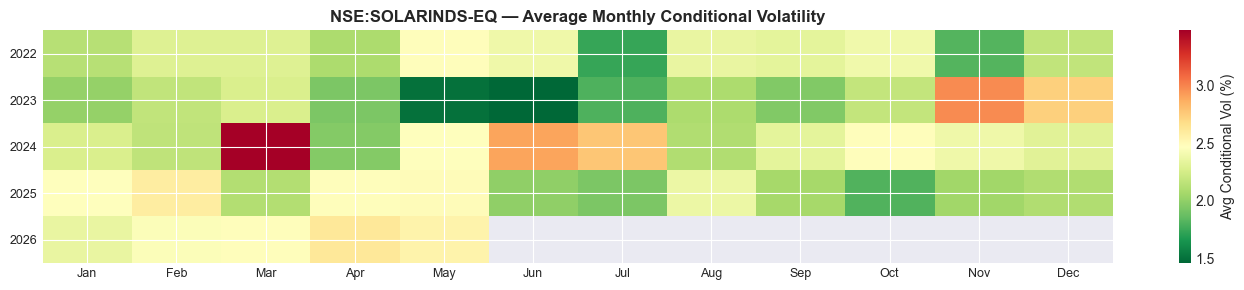

In [15]:
# ── Chart 4: Monthly volatility heatmap ──────────────────────────────────
import calendar

hm = df_daily['cond_vol'].copy()
hm.index = hm.index.tz_localize(None)   # strip tz for pivot

pivot = (hm.groupby([hm.index.year, hm.index.month])
           .mean()
           .unstack(level=1))
pivot.columns = [calendar.month_abbr[m] for m in pivot.columns]

fig, ax = plt.subplots(figsize=(14, max(3, len(pivot) * 0.6)))
im = ax.imshow(pivot.values, aspect='auto', cmap='RdYlGn_r')
ax.set_xticks(range(len(pivot.columns)))
ax.set_xticklabels(pivot.columns, fontsize=9)
ax.set_yticks(range(len(pivot.index)))
ax.set_yticklabels(pivot.index, fontsize=9)
plt.colorbar(im, ax=ax, label='Avg Conditional Vol (%)')
ax.set_title(f'{SYMBOL} — Average Monthly Conditional Volatility', fontweight='bold')
plt.tight_layout()
plt.show()

---
## Step 10: 🔮 Forecast Tomorrow's Volatility

This is the most actionable section — the GARCH model tells us what to
expect for the **next trading session** so you can size positions accordingly.

In [16]:
# ── Forecast next-day conditional volatility ─────────────────────────────
FORECAST_HORIZON = 1   # Days ahead to forecast

forecast    = result.forecast(horizon=FORECAST_HORIZON, reindex=False)
vol_fcast   = np.sqrt(forecast.variance.values[-1])   # convert variance → vol
var_fcast   = vol_fcast * var_mult                     # apply VaR multiplier

last_date   = df_daily.index[-1]
future_dates = pd.bdate_range(last_date, periods=FORECAST_HORIZON + 1, freq='B')[1:]

last_close = df_daily['close'].iloc[-1]
predictions_date = future_dates[0].strftime('%Y-%m-%d')

expected_pct = vol_fcast[0]
expected_pts = last_close * (expected_pct / 100)
range_1s_low = last_close - expected_pts
range_1s_high = last_close + expected_pts

var_pct = abs(var_fcast[0])
var_pts = last_close * (var_pct / 100)
range_var_low = last_close - var_pts
range_var_high = last_close + var_pts

print("========================================================================")
print("   TOMORROW's EXPECTED PRICE RANGE")
print("========================================================================")
print(f"Last close: {last_close:.2f}")
print(f"predictions for: {predictions_date}")
print()
print(f"Expected move (1σ): ±{expected_pts:.2f} points (±{expected_pct:.4f}%)")
print(f" -> Range: {range_1s_low:.2f} to {range_1s_high:.2f}")
print()
print(f"Max move (95% VaR): ±{var_pts:.2f} points (±{var_pct:.4f}%)")
print(f" -> Range: {range_var_low:.2f} to {range_var_high:.2f}")
print("========================================================================")

   TOMORROW's EXPECTED PRICE RANGE
Last close: 18797.00
predictions for: 2026-05-28

Expected move (1σ): ±411.20 points (±2.1876%)
 -> Range: 18385.80 to 19208.20

Max move (95% VaR): ±864.95 points (±4.6016%)
 -> Range: 17932.05 to 19661.95


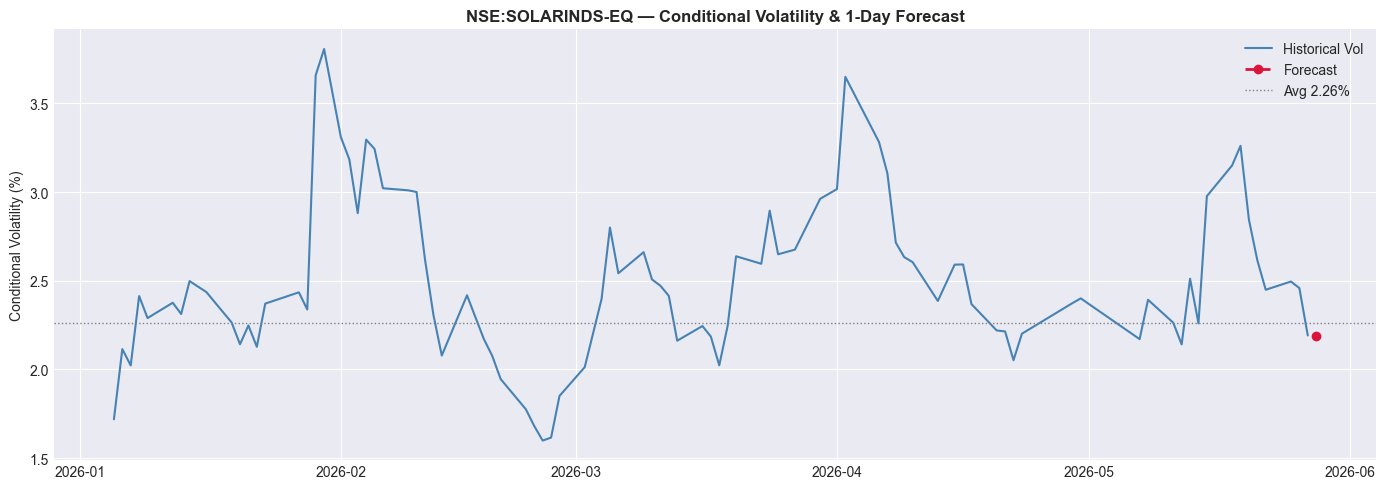

In [17]:
# ── Chart 5: Trailing vol + forecast ─────────────────────────────────────
TAIL_DAYS = 90   # Show last N days of history for context

hist = df_daily['cond_vol'].tail(TAIL_DAYS)

fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(hist.index, hist.values, color='steelblue', linewidth=1.5, label='Historical Vol')
ax.plot(future_dates, vol_fcast, color='crimson', linewidth=2,
        linestyle='--', marker='o', markersize=6, label='Forecast')
ax.axhline(avg_vol, color='gray', linewidth=1, linestyle=':', label=f'Avg {avg_vol:.2f}%')
ax.set_title(f'{SYMBOL} — Conditional Volatility & {FORECAST_HORIZON}-Day Forecast',
             fontweight='bold')
ax.set_ylabel('Conditional Volatility (%)')
ax.legend()
plt.tight_layout()
plt.show()

---
## Summary

| Metric | Value |
|--------|-------|
| Symbol | See `SYMBOL` |
| Model  | `VOL_MODEL(P_LAG, O_LAG, Q_LAG)` with `DIST` distribution |
| Avg conditional vol | `avg_vol` % |
| VaR breach rate | `breach_rt` % (target 5%) |
| Tomorrow's vol forecast | `vol_fcast[0]` % |

**Key takeaways:**
- If `breach_rt ≈ 5%` → the model is well-calibrated.
- High `α + β` (persistence) → expect clustered volatility; widen stops.
- When tomorrow's forecast > average → reduce position size or hedge.